In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Part_A_DS_20221230.csv')


<AxesSubplot: xlabel='Year'>

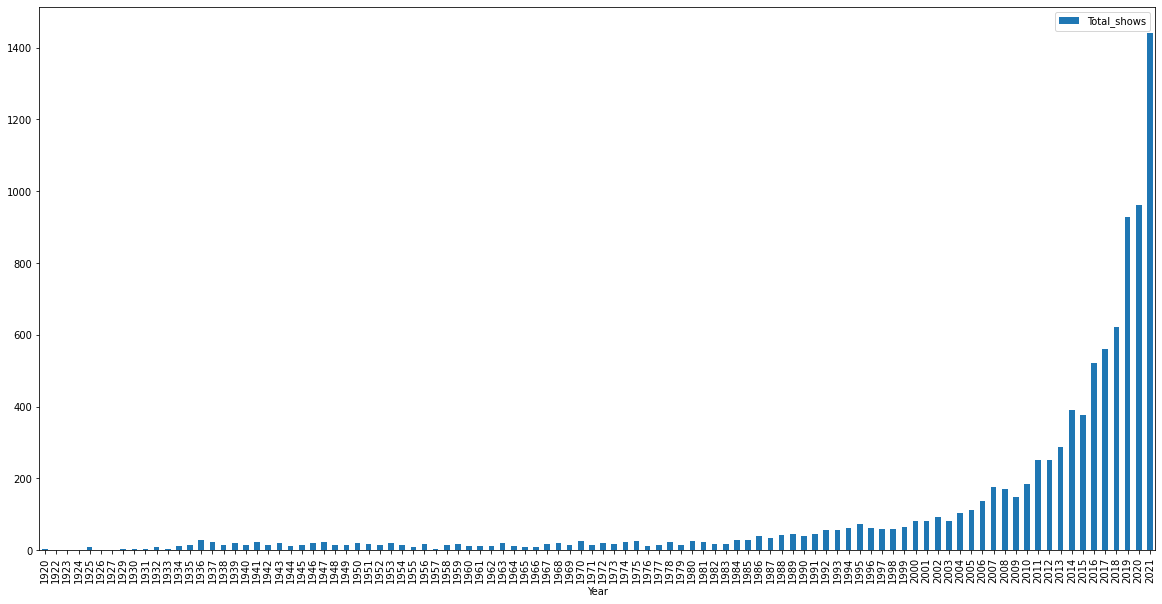

In [3]:
Yearly_tot_shows = pd.DataFrame(df.groupby(['release_year'])['show_id'].count()).reset_index()

Yearly_tot_shows = Yearly_tot_shows.rename(columns={'release_year': 'Year','show_id': 'Total_shows'})

Yearly_tot_shows.plot.bar(x='Year', y='Total_shows', figsize=(20, 10))

In [4]:
#Data Volume Year wise
all_years = pd.DataFrame(df.groupby(['release_year'])['show_id'].count())
all_years['perc'] = all_years['show_id']*100/len(df)
all_years = all_years.sort_values(by = ['release_year'], ascending = False)
all_years['Cum_perc'] = all_years['perc'].cumsum()
all_years = all_years.reset_index()
all_years.loc[all_years['Cum_perc']<95] #Checking when is data >95%

,release_year,show_id,perc,Cum_perc
0,2021,1442,14.915184,14.915184
1,2020,962,9.950352,24.865536
2,2019,929,9.609019,34.474555
3,2018,623,6.443939,40.918494
4,2017,562,5.812991,46.731485
...,...,...,...,...
57,1964,13,0.134464,94.393877
58,1963,20,0.206868,94.600745
59,1962,12,0.124121,94.724866
60,1961,11,0.113777,94.838643


### Drop data before 1960, as it have only 5% data volume

In [5]:
df = df.loc[df['release_year'] > 1960]

<AxesSubplot: xlabel='release_year'>

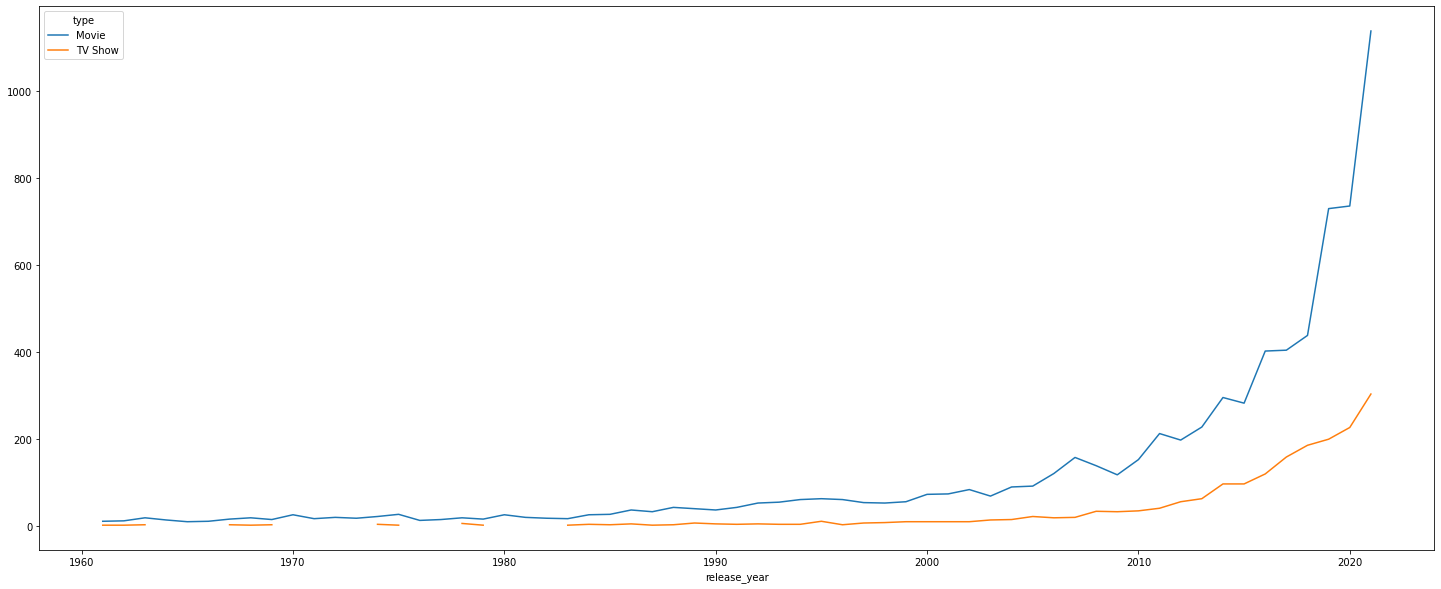

In [6]:
year_wise = pd.DataFrame(df.groupby(['release_year','type'])['show_id'].count()).reset_index()
year_wise.pivot(index='release_year', columns='type', values='show_id').plot.line(figsize=(25, 10))

/var/folders/y5/sqxvp96j7kq4n2yv8qbqmyc80000gn/T/ipykernel_52665/3812618346.py:3: FutureWarning: The default value of regex will change from True to False in a future version.
  df_movie['Movie_min'] = df_movie['duration'].str.replace('([A-Za-z]+)', '').astype(int)
/var/folders/y5/sqxvp96j7kq4n2yv8qbqmyc80000gn/T/ipykernel_52665/3812618346.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movie['Movie_min'] = df_movie['duration'].str.replace('([A-Za-z]+)', '').astype(int)


<AxesSubplot: xlabel='release_year'>

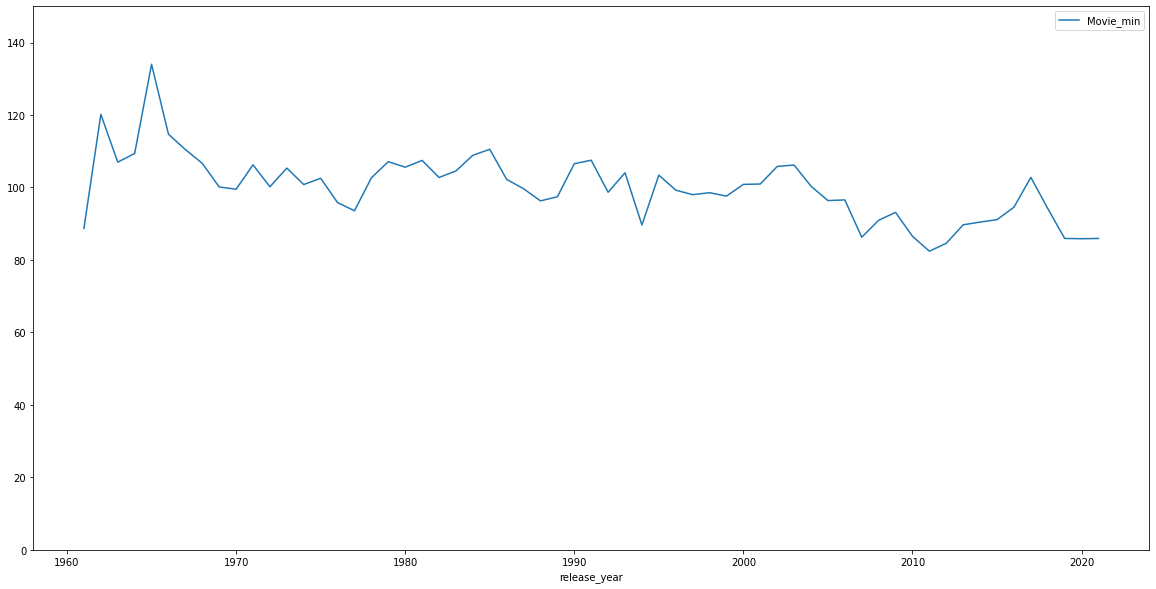

In [11]:
# Analysis on Movies Duration
df_movie = df.loc[df['type'] == 'Movie']
df_movie['Movie_min'] = df_movie['duration'].str.replace('([A-Za-z]+)', '').astype(int)

df_movie_avg = pd.DataFrame(df_movie.groupby(['release_year'])['Movie_min'].mean()).reset_index()
df_movie_avg.plot.line(x='release_year', y='Movie_min',  ylim = (0,150) ,figsize=(20, 10))


###  Insight from above chart: 
- Tv shows came in Trend after 2010
- There is Decline in Avg time duration of the Movies

### Top 10 Countries with most released Movies and Tv shows

In [12]:
Country = pd.DataFrame(df.groupby(['country'])['show_id'].count()).reset_index()

Country_only = Country.assign(country=Country['country'].str.split(',')).explode('country')
Country_only['country'] = Country_only['country'].str.replace(" ","")
Country_only.groupby('country')['show_id'].sum().reset_index().sort_values(by = ['show_id'], ascending = False).head(10)


,country,show_id
44,UnitedStates,328
19,India,246
43,UnitedKingdom,67
7,Canada,35
14,France,20
16,Germany,17
22,Italy,13
38,Spain,11
3,Australia,6
9,China,6


### Top 10 Contents Types for Movies and Tv shows

In [14]:
Content = pd.DataFrame(df.groupby(['listed_in'])['show_id'].count()).reset_index()

Content_only = Content.assign(listed_in=Content['listed_in'].str.split(',')).explode('listed_in')
Content_only['listed_in'] = Content_only['listed_in'].str.replace(" ","")
Content_only.groupby('listed_in')['show_id'].sum().reset_index().sort_values(by = ['show_id'], ascending = False).head(10)


,listed_in,show_id
8,Drama,3447
6,Comedy,1995
0,Action,1543
24,Suspense,1417
16,Kids,1073
7,Documentary,991
22,SpecialInterest,957
14,Horror,850
20,Romance,644
2,Animation,545


###  Same way we can get 
- Overall Top 10 Directors with Most movies 
- Overall Top 10 Cast (Actor/ Actress) with Most movies  
- Most Ratings to the Movies and Tv Shows

### Top Content Type across countries 


In [15]:
Country_content = pd.DataFrame(df.groupby(['country','listed_in'])['show_id'].count()).reset_index()


In [16]:
#Separating the multiple country and content values in mutiple rows
Country_content_1 = Country_content.assign(country=Country_content['country'].str.split(',')).explode('country')
Country_content_2 = Country_content_1.assign(Content=Country_content_1['listed_in'].str.split(',')).explode('Content').reset_index(drop = True)

#After Splitting there is space in country name Prefix
Country_content_2['country'] = Country_content_2['country'].str.replace(" ","")
Country_content_2['Content'] = Country_content_2['Content'].str.replace(" ","")



In [53]:
#Preparing Aggregated table by suming content type across country
Country_content_agg = Country_content_2.groupby(['country','Content'])['show_id'].sum() \
.reset_index().sort_values(by = ['show_id'], ascending = False).reset_index(drop = True)

idx = Country_content_agg.groupby(['country'])['show_id'].transform(max) == Country_content_agg['show_id']
Country_content_agg[idx]

,country,Content,show_id
0,India,Drama,143
2,UnitedStates,Drama,136
16,UnitedKingdom,Drama,22
20,Canada,Drama,14
29,Germany,Drama,9
...,...,...,...
264,Kazakhstan,Comedy,1
265,Luxembourg,Action,1
266,Luxembourg,Adventure,1
267,Luxembourg,Western,1


In [55]:
#QC Data
Country_content_agg[Country_content_agg['country'] == 'India'].head(10)

,country,Content,show_id
0,India,Drama,143
1,India,International,139
5,India,Comedy,71
7,India,Action,48
9,India,Romance,42
10,India,Suspense,41
22,India,andCulture,13
23,India,Entertainment,13
24,India,Arts,13
32,India,Horror,9


### Yearly Top Director with most movies

In [66]:
Yearly_Cast = pd.DataFrame(df.groupby(['release_year','director'])['show_id'].count()).reset_index()


#Separating the multiple country and content values in mutiple rows
Yearly_Cast_1 = Yearly_Cast.assign(director=Yearly_Cast['director'].str.split(',')).explode('director')

#After Splitting there is space in country name Prefix
Yearly_Cast_1['director'] = Yearly_Cast_1['director'].str.replace(" ","")

In [67]:
#Preparing Aggregated table by suming content type across country
Yearly_Cast_agg = Yearly_Cast_1.groupby(['director','release_year'])['show_id'].sum() \
.reset_index().sort_values(by = ['show_id'], ascending = False).reset_index(drop = True)

idx = Yearly_Cast_agg.groupby(['release_year'])['show_id'].transform(max) == Yearly_Cast_agg['show_id']
Yearly_Cast_agg[idx].sort_values(by = ['release_year'], ascending = False)

,director,release_year,show_id
7,1,2021,16
5,MoonbugEntertainment,2020,22
0,CannisHolder,2019,39
18,CannisHolder,2018,9
4,MarkKnight,2017,22
...,...,...,...
3722,CurtisHarrington,1961,1
5365,JohnSturges,1961,1
5411,JohnLemont,1961,1
3407,SamPeckinpah,1961,1


In [69]:
#QC Data
Yearly_Cast_agg[Yearly_Cast_agg['release_year'] == 2021].head(10)

,director,release_year,show_id
7,1,2021,16
11,MoraTV,2021,10
19,MoonbugEntertainment,2021,9
27,ArthurMerkulov,2021,6
29,LokeshKanagaraj,2021,6
30,Pinkfong,2021,6
31,VladimirGerasimov,2021,6
33,NikitaYurov,2021,6
47,ChrisSeaver,2021,4
50,ScottJeffrey,2021,4


## Same way we can perform
- Each Year Top Cast with most movies
- Each Year Most Ratings to the movies 
- Top Movie and TV shows content across all years
- Top Cast selected by Directors
- Top Content type for Directors
- Most Seasons for the TV Series